In [11]:
import json
import os

# Vérifier le JSON
with open("practice_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("✅ JSON chargé !")

# Compter les images avec annotations
total_images = 0
total_fields = 0

for session in data["practice_sessions"]:
    for collection in session["collections"]:
        for img in collection["interactive_images"]:
            if img["image"] and img["fields"]:
                total_images += 1
                total_fields += len(img["fields"])

print(f"📸 Images avec annotations : {total_images}")
print(f"🏷️  Total champs annotés : {total_fields}")

✅ JSON chargé !
📸 Images avec annotations : 23
🏷️  Total champs annotés : 44


In [12]:
# Pour definir les classes yolo

# Voir la distribution des types de champs
from collections import Counter

field_types = []

for session in data["practice_sessions"]:
    for collection in session["collections"]:
        for img in collection["interactive_images"]:
            for field in img["fields"]:
                field_types.append(field["field_type"])

counter = Counter(field_types)
print("=== TYPES DE CHAMPS DÉTECTÉS ===")
for field_type, count in counter.most_common():
    print(f"  {field_type}: {count}")

=== TYPES DE CHAMPS DÉTECTÉS ===
  text: 17
  button: 16
  button_filled: 10
  checkbox: 1


In [13]:
# converting json en format yolo

import os
import shutil
from PIL import Image

# Créer la structure de dossiers YOLO
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)

# Classes YOLO
classes = {
    "text": 0,
    "button": 1, 
    "button_filled": 2,
    "checkbox": 3
}

converted = 0
skipped = 0

for session in data["practice_sessions"]:
    for collection in session["collections"]:
        for img in collection["interactive_images"]:
            
            # Skip si pas d'image ou pas de champs
            if not img["image"] or not img["fields"]:
                skipped += 1
                continue
            
            image_id = img["image_id"]
            image_src = img["image"]  # chemin relatif dans le zip
            
            # Chercher l'image dans le dossier images
            image_full_path = image_src  # déjà le bon chemin
            
            if not os.path.exists(image_full_path):
                print(f"⚠️ Image non trouvée : {image_full_path}")
                skipped += 1
                continue
            
            # Copier l'image dans dataset/images/train
            dest_image = f"dataset/images/train/{image_id}.png"
            shutil.copy(image_full_path, dest_image)
            
            # Créer le fichier d'annotations YOLO
            label_path = f"dataset/labels/train/{image_id}.txt"
            
            with open(label_path, "w") as label_file:
                for field in img["fields"]:
                    field_type = field["field_type"]
                    class_id = classes[field_type]
                    
                    # Position en % dans le JSON → format YOLO
                    # YOLO attend : class x_center y_center width height (tous en 0-1)
                    x = field["position"]["x"] / 100
                    y = field["position"]["y"] / 100
                    w = field["position"]["width"] / 100
                    h = field["position"]["height"] / 100
                    
                    # YOLO veut le centre, pas le coin
                    x_center = x + w/2
                    y_center = y + h/2
                    
                    label_file.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
            
            converted += 1

print(f"✅ {converted} images converties")
print(f"⚠️ {skipped} images skippées")

✅ 23 images converties
⚠️ 2 images skippées


In [14]:
# Compter ce qu'on a
images = os.listdir("dataset/images/train")
labels = os.listdir("dataset/labels/train")

print(f"📸 Images : {len(images)}")
print(f"🏷️  Labels : {len(labels)}")

# Voir un exemple de label
print("\n=== EXEMPLE DE LABEL ===")
with open(f"dataset/labels/train/{labels[0]}", "r") as f:
    print(f.read())

📸 Images : 25
🏷️  Labels : 25

=== EXEMPLE DE LABEL ===
## This file was auto generated by the Azure Machine Learning Studio. Please do not remove. 
## Read more about the .amlignore file here: https://docs.microsoft.com/azure/machine-learning/how-to-save-write-experiment-files#storage-limits-of-experiment-snapshots
        
.ipynb_aml_checkpoints/ 
*.amltmp 
*.amltemp


In [15]:
import os

# Trouver où on est exactement
current_dir = os.getcwd()
print(f"📍 On est ici : {current_dir}")

# Vérifier que le dataset existe
dataset_path = os.path.join(current_dir, "dataset")
print(f"📁 Dataset path : {dataset_path}")
print(f"✅ Existe : {os.path.exists(dataset_path)}")

📍 On est ici : /mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/test_tuning
📁 Dataset path : /mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/test_tuning/dataset
✅ Existe : True


In [30]:
import os, shutil, random, json

# ── Nettoyer les anciens dossiers ─────────────────────────────
for split in ["train", "test"]:
    for folder in ["images", "labels"]:
        path = f"dataset/{folder}/{split}"
        if os.path.exists(path):
            shutil.rmtree(path)
        os.makedirs(path)

print("🗑️ Anciens dossiers nettoyés")

classes = {"text": 0, "button": 1, "button_filled": 2, "checkbox": 3}

# ── Collecter toutes les images annotées ──────────────────────
all_images = []
for session in data["practice_sessions"]:
    for collection in session["collections"]:
        for img in collection["interactive_images"]:
            if img["image"] and img["fields"]:
                all_images.append(img)

print(f"📸 Total images disponibles : {len(all_images)}")

# ── Split STRICT 18 train / 5 test SANS overlap ───────────────
random.seed(42)
random.shuffle(all_images)

# S'assurer que les IDs sont uniques
seen_ids = set()
unique_images = []
for img in all_images:
    if img["image_id"] not in seen_ids:
        unique_images.append(img)
        seen_ids.add(img["image_id"])

print(f"📸 Images uniques : {len(unique_images)}")

train_images = unique_images[:18]
test_images  = unique_images[18:]  # les 5 dernières, jamais vues en train

print(f"✅ Train : {len(train_images)} images")
print(f"✅ Test  : {len(test_images)} images")

# Vérifier overlap
train_ids_new = {img["image_id"] for img in train_images}
test_ids_new  = {img["image_id"] for img in test_images}
overlap = train_ids_new & test_ids_new
print(f"🔍 Overlap train/test : {len(overlap)} ← doit être 0")

# ── Copier images + labels ────────────────────────────────────
def process_split(image_list, split):
    for img in image_list:
        image_id = img["image_id"]
        image_src = img["image"]

        if not os.path.exists(image_src):
            print(f"⚠️ Image non trouvée : {image_src}")
            continue

        shutil.copy(image_src, f"dataset/images/{split}/{image_id}.png")

        with open(f"dataset/labels/{split}/{image_id}.txt", "w") as f:
            for field in img["fields"]:
                class_id = classes[field["field_type"]]
                x = field["position"]["x"] / 100
                y = field["position"]["y"] / 100
                w = field["position"]["width"]  / 100
                h = field["position"]["height"] / 100
                x_center = x + w/2
                y_center = y + h/2
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

process_split(train_images, "train")
process_split(test_images,  "test")

print("\n🎉 Split propre terminé !")
print(f"   Train IDs : {sorted(train_ids_new)}")
print(f"   Test  IDs : {sorted(test_ids_new)}")

🗑️ Anciens dossiers nettoyés
📸 Total images disponibles : 23
📸 Images uniques : 23
✅ Train : 18 images
✅ Test  : 5 images
🔍 Overlap train/test : 0 ← doit être 0

🎉 Split propre terminé !
   Train IDs : ['img_1767540423106', 'img_1767541016812', 'img_1767542245506', 'img_1767551755550', 'img_1767551919967', 'img_1767552400703', 'img_1767552548532', 'img_1767552632022', 'img_1767552714000', 'img_1767552835774', 'img_1767553380140', 'img_1767553758929', 'img_1768290386243', 'img_1768295112745', 'img_1768297614288', 'img_1768297974659', 'img_1768298450246', 'img_1768298592151']
   Test  IDs : ['img_1767525774023', 'img_1767541389301', 'img_1767552014121', 'img_1767552228211', 'img_1768298110608']


In [16]:
# import os
# import shutil
# import random
# import json

# current_dir = os.getcwd()
# dataset_path = os.path.join(current_dir, "dataset")

# # Créer les dossiers train ET test
# os.makedirs("dataset/images/train", exist_ok=True)
# os.makedirs("dataset/labels/train", exist_ok=True)
# os.makedirs("dataset/images/test", exist_ok=True)
# os.makedirs("dataset/labels/test", exist_ok=True)

# classes = {"text": 0, "button": 1, "button_filled": 2, "checkbox": 3}

# # Collecter toutes les images annotées
# all_images = []
# for session in data["practice_sessions"]:
#     for collection in session["collections"]:
#         for img in collection["interactive_images"]:
#             if img["image"] and img["fields"]:
#                 all_images.append(img)

# # Split 18 train / 5 test
# random.seed(42)
# random.shuffle(all_images)
# train_images = all_images[:18]
# test_images = all_images[18:]

# print(f"✅ Train : {len(train_images)} images")
# print(f"✅ Test  : {len(test_images)} images")

# # Fonction pour convertir et copier
# def process_images(image_list, split):
#     for img in image_list:
#         image_id = img["image_id"]
#         image_src = img["image"]
        
#         if not os.path.exists(image_src):
#             print(f"⚠️ Non trouvée : {image_src}")
#             continue
        
#         # Copier image
#         shutil.copy(image_src, f"dataset/images/{split}/{image_id}.png")
        
#         # Créer label YOLO
#         with open(f"dataset/labels/{split}/{image_id}.txt", "w") as f:
#             for field in img["fields"]:
#                 class_id = classes[field["field_type"]]
#                 x = field["position"]["x"] / 100
#                 y = field["position"]["y"] / 100
#                 w = field["position"]["width"] / 100
#                 h = field["position"]["height"] / 100
#                 x_center = x + w/2
#                 y_center = y + h/2
#                 f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# process_images(train_images, "train")
# process_images(test_images, "test")

# print("🎉 Dataset splitté et prêt !")

✅ Train : 18 images
✅ Test  : 5 images
🎉 Dataset splitté et prêt !


In [31]:
from ultralytics import YOLO

config = f"""path: {dataset_path}
train: images/train
val: images/test

nc: 4
names:
  0: text
  1: button
  2: button_filled
  3: checkbox
"""

config_path = os.path.join(dataset_path, "config.yaml")
with open(config_path, "w") as f:
    f.write(config)

print("✅ Config créée !")

model = YOLO("yolov8n.pt")
model.train(
    data=config_path,
    epochs=50,
    imgsz=1280,
    batch=4,
    device="cpu",
    patience=10,
    project="runs",
    name="erp_detector"
)

print("🎉 Fine-tuning terminé !")

✅ Config créée !
New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.70 🚀 Python-3.10.19 torch-2.10.0+cu128 CPU (Intel Xeon CPU E5-2673 v4 @ 2.30GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/test_tuning/dataset/config.yaml, epochs=50, time=None, patience=10, batch=4, imgsz=1280, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=runs, name=erp_detector5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_

       1/50         0G      3.421      9.399      2.472          3       1280: 100%|██████████| 5/5 [00:19<00:00,  3.96s/it]st_tuning/dataset/labels/train... 7 images, 0 backgrounds, 0 corrupt:  39%|███▉      | 7/18 [00:00<00:00, 61.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]
       2/50         0G      3.028      7.951      2.258          3       1280: 100%|██████████| 5/5 [00:18<00:00,  3.76s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]
       3/50         0G      2.804      7.804      2.113          6       1280: 100%|██████████| 5/5 [00:19<00:00,  3.81s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]
       4/50         0G      2.733      8.785      2.134          4       1280: 100%|██████████| 5/5 [00:17<00:00,  3.50s/it]


In [32]:
import os

# Chercher où sont les résultats du training
for root, dirs, files in os.walk("runs"):
    for file in files:
        print(os.path.join(root, file))

runs/erp_detector/args.yaml
runs/erp_detector2/.amlignore
runs/erp_detector2/.amlignore.amltmp
runs/erp_detector2/args.yaml
runs/erp_detector2/confusion_matrix.png
runs/erp_detector2/confusion_matrix_normalized.png
runs/erp_detector2/F1_curve.png
runs/erp_detector2/labels.jpg
runs/erp_detector2/labels_correlogram.jpg
runs/erp_detector2/PR_curve.png
runs/erp_detector2/P_curve.png
runs/erp_detector2/results.csv
runs/erp_detector2/results.png
runs/erp_detector2/R_curve.png
runs/erp_detector2/train_batch0.jpg
runs/erp_detector2/train_batch1.jpg
runs/erp_detector2/train_batch2.jpg
runs/erp_detector2/train_batch240.jpg
runs/erp_detector2/train_batch241.jpg
runs/erp_detector2/train_batch242.jpg
runs/erp_detector2/val_batch0_labels.jpg
runs/erp_detector2/val_batch0_pred.jpg
runs/erp_detector2/val_batch1_labels.jpg
runs/erp_detector2/val_batch1_pred.jpg
runs/erp_detector2/val_batch2_labels.jpg
runs/erp_detector2/val_batch2_pred.jpg
runs/erp_detector2/weights/best.pt
runs/erp_detector2/weights/l

In [43]:
from ultralytics import YOLO

# Le bon chemin — erp_detector4 est le dernier run
model_finetuned = YOLO("runs/erp_detector5/weights/best.pt")
print("✅ Modèle fine-tuné chargé !")

test_images = os.listdir("dataset/images/test")
print(f"📸 Images de test : {len(test_images)}")
for img in test_images:
    print(f"   - {img}")



✅ Modèle fine-tuné chargé !
📸 Images de test : 5
   - img_1767525774023.png
   - img_1767541389301.png
   - img_1767552014121.png
   - img_1767552228211.png
   - img_1768298110608.png


In [44]:
import json, os
from PIL import Image

JSON_PATH      = "practice_data.json"
IOU_THRESHOLD  = 0.3
CONF_THRESHOLD = 0.05   # plus bas que OmniParser car modèle spécialisé

def pct_to_px(pos, W, H):
    x = pos["x"] / 100 * W
    y = pos["y"] / 100 * H
    w = pos["width"]  / 100 * W
    h = pos["height"] / 100 * H
    return [x, y, x+w, y+h]

def compute_iou(A, B):
    xA, yA = max(A[0], B[0]), max(A[1], B[1])
    xB, yB = min(A[2], B[2]), min(A[3], B[3])
    inter  = max(0, xB-xA) * max(0, yB-yA)
    union  = (A[2]-A[0])*(A[3]-A[1]) + (B[2]-B[0])*(B[3]-B[1]) - inter
    return inter/union if union > 0 else 0

# Charger le JSON
with open(JSON_PATH) as f:
    data = json.load(f)

# Index image_id → champs annotés
annotations = {}
for session in data["practice_sessions"]:
    for col in session["collections"]:
        for img in col["interactive_images"]:
            if not img["fields"] or not img["image"]:
                continue
            W, H = img["screenshot_width"], img["screenshot_height"]
            annotations[img["image_id"]] = {
                "fields": [
                    {
                        "name":  f["name"],
                        "type":  f["field_type"],
                        "bbox":  pct_to_px(f["position"], W, H)
                    }
                    for f in img["fields"]
                ],
                "W": W, "H": H
            }

# Évaluer uniquement sur les 5 images de test
results_all = []
test_image_ids = [f.replace(".png", "") for f in os.listdir("dataset/images/test")]

for image_id in test_image_ids:
    if image_id not in annotations:
        print(f"⚠️ {image_id} pas dans le JSON")
        continue

    img_path = f"dataset/images/test/{image_id}.png"
    ann      = annotations[image_id]
    gt_boxes = [f["bbox"] for f in ann["fields"]]

    # Détections YOLOv8 fine-tuné
    det        = model_finetuned(img_path, verbose=False)
    pred_boxes = [
        b.xyxy[0].tolist()
        for b in det[0].boxes
        if float(b.conf) >= CONF_THRESHOLD
    ]

    # Matching IoU
    matched_gt, matched_pred = set(), set()
    for gi, gt in enumerate(gt_boxes):
        best_iou, best_pi = 0, -1
        for pi, pred in enumerate(pred_boxes):
            iou = compute_iou(gt, pred)
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_THRESHOLD and best_pi not in matched_pred:
            matched_gt.add(gi)
            matched_pred.add(best_pi)

    TP = len(matched_gt)
    FP = len(pred_boxes) - len(matched_pred)
    FN = len(gt_boxes)   - TP
    P  = TP/(TP+FP) if (TP+FP) > 0 else 0
    R  = TP/(TP+FN) if (TP+FN) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0

    results_all.append({
        "image_id": image_id,
        "GT": len(gt_boxes), "Det": len(pred_boxes),
        "TP": TP, "FP": FP, "FN": FN,
        "P": round(P,3), "R": round(R,3), "F1": round(F1,3)
    })

    print(f"[{image_id[:35]}]")
    print(f"   GT={len(gt_boxes)} | Det={len(pred_boxes)} | TP={TP} FP={FP} FN={FN}")
    print(f"   Precision={P:.2f} | Recall={R:.2f} | F1={F1:.2f}\n")

# Résultats globaux
tTP = sum(r["TP"] for r in results_all)
tFP = sum(r["FP"] for r in results_all)
tFN = sum(r["FN"] for r in results_all)
P_g = tTP/(tTP+tFP) if (tTP+tFP)>0 else 0
R_g = tTP/(tTP+tFN) if (tTP+tFN)>0 else 0
F_g = 2*P_g*R_g/(P_g+R_g) if (P_g+R_g)>0 else 0
model_mb = os.path.getsize("runs/erp_detector5/weights/best.pt")/1024/1024

print(f"""
{'='*50}
  YOLOv8 FINE-TUNÉ — RÉSULTATS TEST SET
{'='*50}
  Images testées  : {len(results_all)}
  Champs annotés  : {tTP+tFN}
  TP={tTP}  FP={tFP}  FN={tFN}
  Precision : {P_g:.3f}  ({P_g*100:.1f}%)
  Recall    : {R_g:.3f}  ({R_g*100:.1f}%)
  F1 Score  : {F_g:.3f}  ({F_g*100:.1f}%)
  Poids modèle : {model_mb:.1f} MB
{'='*50}
""")

[img_1767525774023]
   GT=5 | Det=0 | TP=0 FP=0 FN=5
   Precision=0.00 | Recall=0.00 | F1=0.00

[img_1767541389301]
   GT=1 | Det=0 | TP=0 FP=0 FN=1
   Precision=0.00 | Recall=0.00 | F1=0.00

[img_1767552014121]
   GT=5 | Det=0 | TP=0 FP=0 FN=5
   Precision=0.00 | Recall=0.00 | F1=0.00

[img_1767552228211]
   GT=1 | Det=0 | TP=0 FP=0 FN=1
   Precision=0.00 | Recall=0.00 | F1=0.00

[img_1768298110608]
   GT=2 | Det=0 | TP=0 FP=0 FN=2
   Precision=0.00 | Recall=0.00 | F1=0.00


  YOLOv8 FINE-TUNÉ — RÉSULTATS TEST SET
  Images testées  : 5
  Champs annotés  : 14
  TP=0  FP=0  FN=14
  Precision : 0.000  (0.0%)
  Recall    : 0.000  (0.0%)
  F1 Score  : 0.000  (0.0%)
  Poids modèle : 6.0 MB



In [35]:
# Filtrer uniquement les .png
test_image_ids = [
    f.replace(".png", "") 
    for f in os.listdir("dataset/images/test") 
    if f.endswith(".png")  # ← seulement les images
]

print(f"📸 Images de test : {len(test_image_ids)}")
for img in test_image_ids:
    print(f"   - {img}")

📸 Images de test : 5
   - img_1767525774023
   - img_1767541389301
   - img_1767552014121
   - img_1767552228211
   - img_1768298110608


In [42]:
# Voir exactement ce que le modèle fine-tuné détecte sur les images de test
for image_id in test_image_ids:
    img_path = f"dataset/images/test/{image_id}.png"
    det = model_finetuned(img_path, verbose=False, conf=0.01)  # seuil très bas
    
    print(f"\n[{image_id[:30]}]")
    if len(det[0].boxes) == 0:
        print("   ❌ Aucune détection même à conf=0.01")
    else:
        for b in det[0].boxes:
            print(f"   {det[0].names[int(b.cls)]} — conf={float(b.conf):.3f}")


[img_1767525774023]
   text — conf=0.224
   text — conf=0.079
   text — conf=0.053
   text — conf=0.044
   text — conf=0.037
   text — conf=0.034
   button — conf=0.031
   text — conf=0.028
   text — conf=0.026
   text — conf=0.025
   text — conf=0.025
   text — conf=0.022
   text — conf=0.021
   text — conf=0.016
   text — conf=0.015
   text — conf=0.015
   text — conf=0.014
   text — conf=0.014
   button — conf=0.013
   text — conf=0.013
   text — conf=0.013
   text — conf=0.013
   text — conf=0.013
   text — conf=0.012
   text — conf=0.011
   button — conf=0.010
   button — conf=0.010
   text — conf=0.010

[img_1767541389301]
   text — conf=0.139
   text — conf=0.085
   text — conf=0.078
   text — conf=0.074
   text — conf=0.063
   text — conf=0.063
   text — conf=0.053
   button — conf=0.050
   text — conf=0.035
   text — conf=0.034
   text — conf=0.025
   text — conf=0.024
   text — conf=0.022
   text — conf=0.021
   text — conf=0.019
   text — conf=0.018
   text — conf=0.017
   

In [36]:
%matplotlib inline
import matplotlib
matplotlib.use('Agg')  # pour Azure ML

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Choisir une image de test
IMAGE_ID = test_image_ids[0]
ann      = annotations[IMAGE_ID]
img_path = f"dataset/images/test/{IMAGE_ID}.png"
img      = Image.open(img_path)
W, H     = img.size

# Détections
det        = model_finetuned(img_path, verbose=False)
pred_boxes = [
    {"bbox": b.xyxy[0].tolist(), "conf": float(b.conf),
     "class": det[0].names[int(b.cls)]}
    for b in det[0].boxes if float(b.conf) >= CONF_THRESHOLD
]

fig, axes = plt.subplots(1, 2, figsize=(28, 14))
for ax in axes:
    ax.imshow(img)
    ax.axis('off')

# Gauche : JSON (bleu)
for f in ann["fields"]:
    x1,y1,x2,y2 = f["bbox"]
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
             linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.15)
    axes[0].add_patch(rect)
    axes[0].text(x1, y1-6, f["name"], color='blue', fontsize=8,
                 fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))
axes[0].set_title(f"JSON — {len(ann['fields'])} champs annotés", color='blue', fontsize=13)

# Droite : YOLOv8 fine-tuné (vert)
for b in pred_boxes:
    x1,y1,x2,y2 = b["bbox"]
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
             linewidth=2, edgecolor='green', facecolor='green', alpha=0.15)
    axes[1].add_patch(rect)
    axes[1].text(x1, y1-6, f"{b['class']} {b['conf']:.2f}",
                 color='green', fontsize=8,
                 bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))
axes[1].set_title(f"YOLOv8 fine-tuné — {len(pred_boxes)} détections", color='green', fontsize=13)

plt.tight_layout()

# Sauvegarder ET afficher
output_path = f"eval_{IMAGE_ID}.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Image sauvegardée : {output_path}")

✅ Image sauvegardée : eval_img_1767525774023.png


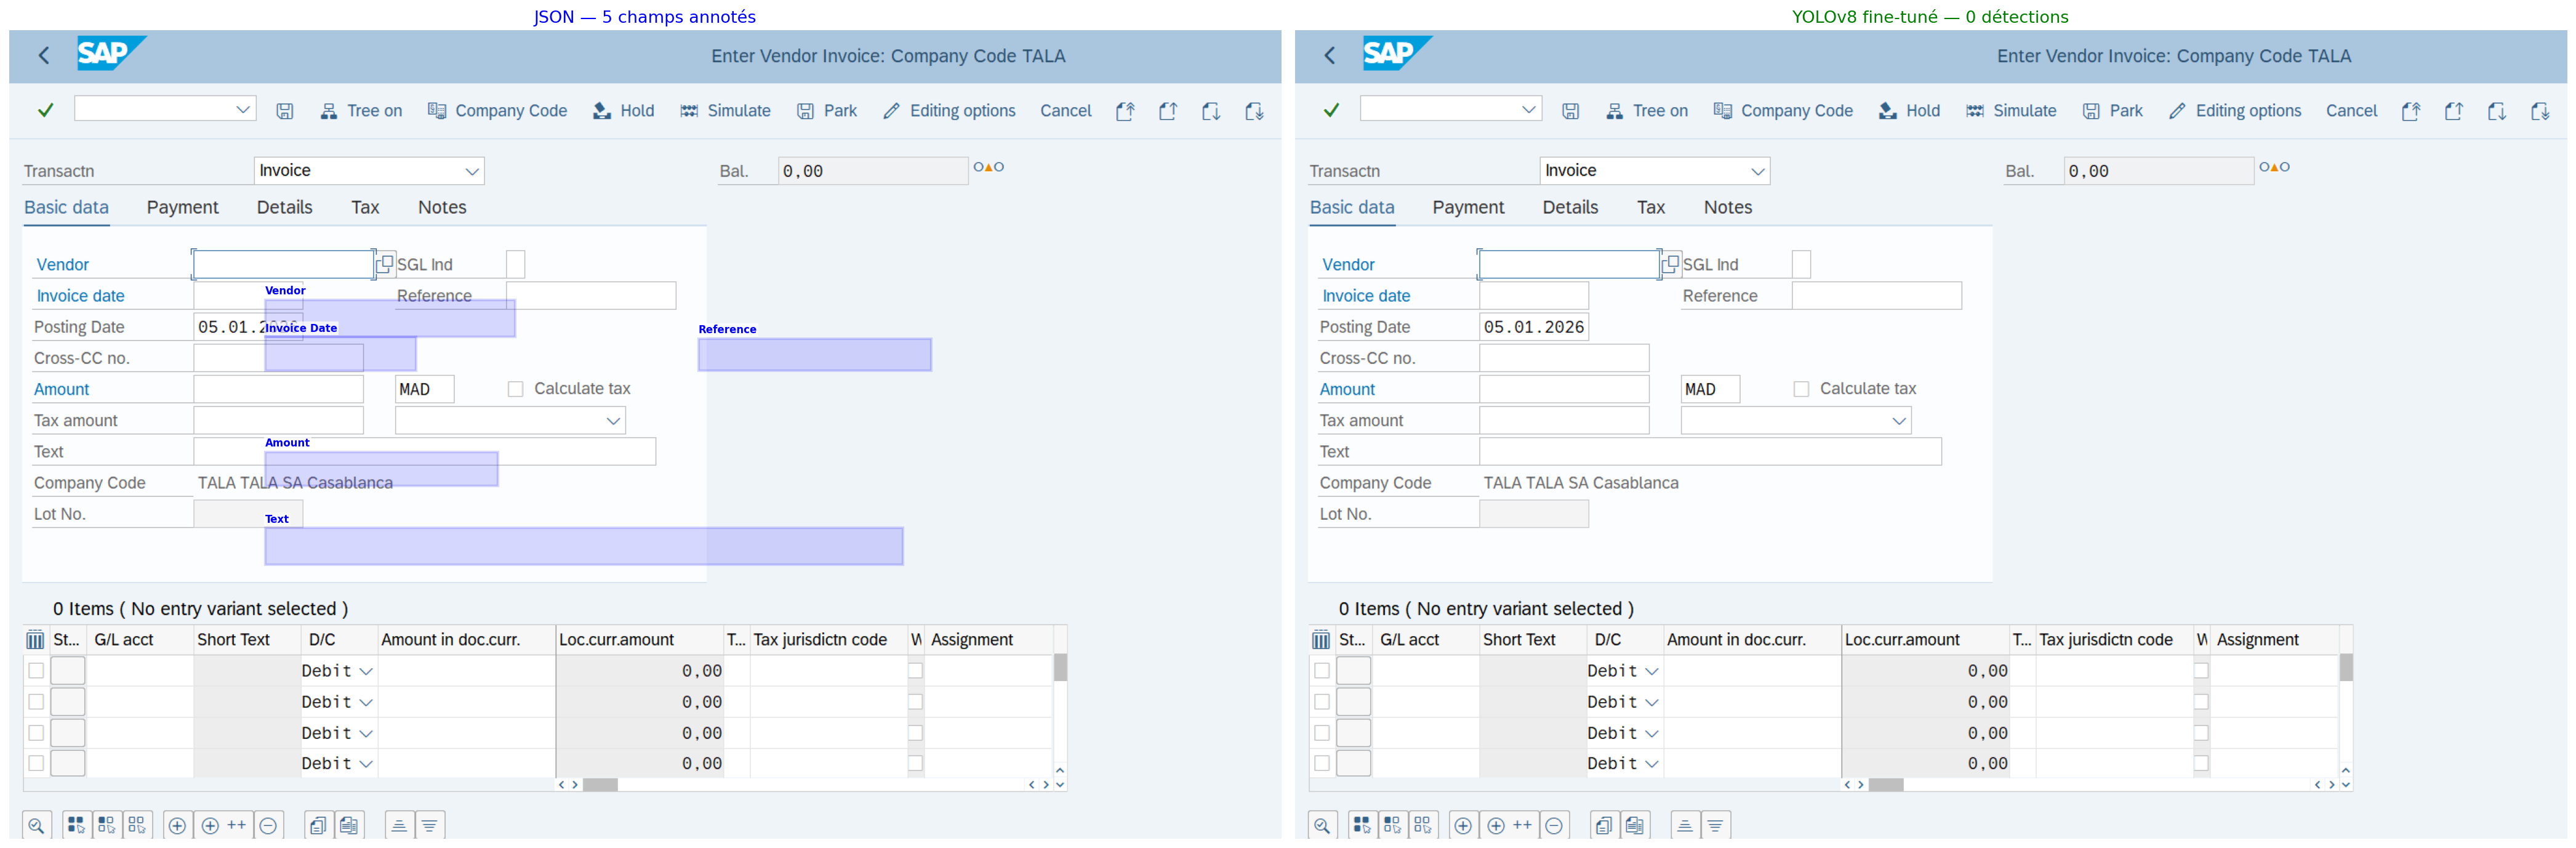

In [37]:
from IPython.display import Image as IPImage, display
display(IPImage(filename=f"eval_{IMAGE_ID}.png", width=1200))

📦 yolov8n base     : 6.2 MB | 1 détections
📦 yolov8n fine-tuné: 6.0 MB   | 1 détections


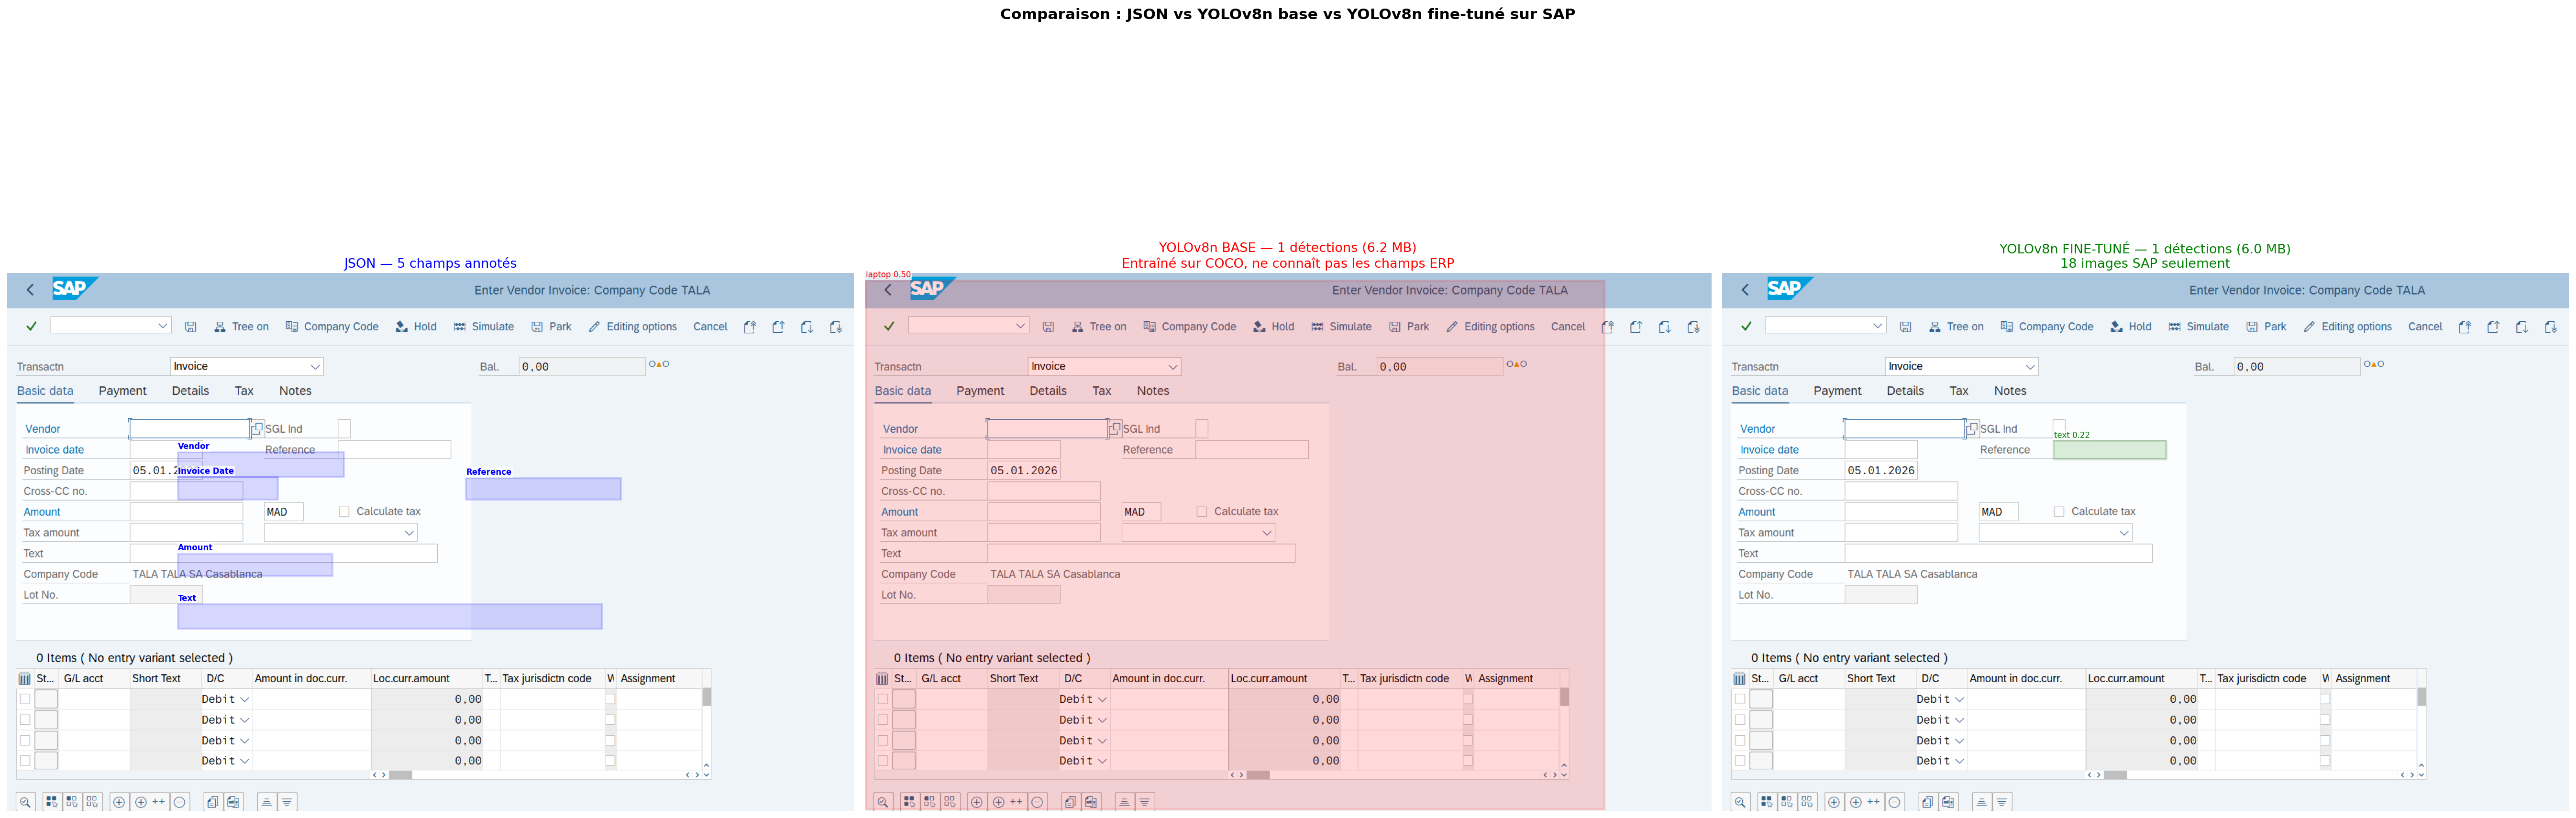

✅ Comparaison sauvegardée !


In [38]:
from ultralytics import YOLO
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

# Charger yolov8n BASE (sans fine-tuning)
model_base = YOLO("yolov8n.pt")

# Même image de test
IMAGE_ID = test_image_ids[0]
img_path = f"dataset/images/test/{IMAGE_ID}.png"
img      = Image.open(img_path)

# Détections sans fine-tuning
det_base = model_base(img_path, verbose=False, conf=0.1)
pred_base = [
    {"bbox": b.xyxy[0].tolist(), "conf": float(b.conf),
     "class": det_base[0].names[int(b.cls)]}
    for b in det_base[0].boxes
]

# Détections avec fine-tuning
det_ft = model_finetuned(img_path, verbose=False, conf=0.1)
pred_ft = [
    {"bbox": b.xyxy[0].tolist(), "conf": float(b.conf),
     "class": det_ft[0].names[int(b.cls)]}
    for b in det_ft[0].boxes
]

# Poids des modèles
size_base = os.path.getsize("yolov8n.pt") / 1024 / 1024
size_ft   = os.path.getsize("runs/erp_detector5/weights/best.pt") / 1024 / 1024

print(f"📦 yolov8n base     : {size_base:.1f} MB | {len(pred_base)} détections")
print(f"📦 yolov8n fine-tuné: {size_ft:.1f} MB   | {len(pred_ft)} détections")

# Visualisation 3 colonnes : JSON | Base | Fine-tuné
fig, axes = plt.subplots(1, 3, figsize=(36, 14))
for ax in axes:
    ax.imshow(img)
    ax.axis('off')

# ── Gauche : JSON ─────────────────────────────────────────────
for f in annotations[IMAGE_ID]["fields"]:
    x1,y1,x2,y2 = f["bbox"]
    axes[0].add_patch(patches.Rectangle(
        (x1,y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.15))
    axes[0].text(x1, y1-6, f["name"], color='blue', fontsize=8,
                 fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))
axes[0].set_title(
    f"JSON — {len(annotations[IMAGE_ID]['fields'])} champs annotés",
    color='blue', fontsize=13)

# ── Milieu : yolov8n SANS fine-tuning (rouge) ─────────────────
if pred_base:
    for b in pred_base:
        x1,y1,x2,y2 = b["bbox"]
        axes[1].add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='red', alpha=0.15))
        axes[1].text(x1, y1-6, f"{b['class']} {b['conf']:.2f}",
                     color='red', fontsize=8,
                     bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))
else:
    axes[1].text(0.5, 0.5, "Aucune détection ERP\n(classes COCO uniquement)",
                 ha='center', va='center', transform=axes[1].transAxes,
                 fontsize=14, color='red',
                 bbox=dict(facecolor='white', alpha=0.8, pad=10))

axes[1].set_title(
    f"YOLOv8n BASE — {len(pred_base)} détections ({size_base:.1f} MB)\nEntraîné sur COCO, ne connaît pas les champs ERP",
    color='red', fontsize=13)

# ── Droite : yolov8n AVEC fine-tuning (vert) ──────────────────
for b in pred_ft:
    x1,y1,x2,y2 = b["bbox"]
    axes[2].add_patch(patches.Rectangle(
        (x1,y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='green', facecolor='green', alpha=0.15))
    axes[2].text(x1, y1-6, f"{b['class']} {b['conf']:.2f}",
                 color='green', fontsize=8,
                 bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))

axes[2].set_title(
    f"YOLOv8n FINE-TUNÉ — {len(pred_ft)} détections ({size_ft:.1f} MB)\n18 images SAP seulement",
    color='green', fontsize=13)

plt.suptitle(
    "Comparaison : JSON vs YOLOv8n base vs YOLOv8n fine-tuné sur SAP",
    fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("comparison_base_vs_finetuned.png", dpi=150, bbox_inches='tight')
display(IPImage(filename="comparison_base_vs_finetuned.png", width=1400))
print("✅ Comparaison sauvegardée !")

In [39]:
# Détections sans fine-tuning avec seuil très bas
det_base = model_base(img_path, verbose=False, conf=0.01)
pred_base = [
    {"bbox": b.xyxy[0].tolist(), "conf": float(b.conf),
     "class": det_base[0].names[int(b.cls)]}
    for b in det_base[0].boxes
]

print(f"Détections base (conf≥0.01) : {len(pred_base)}")
for b in pred_base:
    print(f"  {b['class']} — conf={b['conf']:.2f}")

Détections base (conf≥0.01) : 2
  laptop — conf=0.50
  tv — conf=0.05


In [40]:
# Voir exactement quelles images sont dans train vs test
train_ids = [f.replace(".png", "") for f in os.listdir("dataset/images/train") if f.endswith(".png")]
test_ids  = [f.replace(".png", "") for f in os.listdir("dataset/images/test")  if f.endswith(".png")]

print(f"📚 Train ({len(train_ids)} images):")
for i in train_ids:
    print(f"   - {i}")

print(f"\n🧪 Test ({len(test_ids)} images):")
for i in test_ids:
    print(f"   - {i}")

print(f"\n🔍 Image utilisée : {IMAGE_ID}")
print(f"   Dans train ? {'✅ OUI ← PROBLÈME' if IMAGE_ID in train_ids else '✅ NON — correct'}")
print(f"   Dans test  ? {'✅ OUI — correct'  if IMAGE_ID in test_ids  else '❌ NON — problème'}")

📚 Train (18 images):
   - img_1767540423106
   - img_1767541016812
   - img_1767542245506
   - img_1767551755550
   - img_1767551919967
   - img_1767552400703
   - img_1767552548532
   - img_1767552632022
   - img_1767552714000
   - img_1767552835774
   - img_1767553380140
   - img_1767553758929
   - img_1768290386243
   - img_1768295112745
   - img_1768297614288
   - img_1768297974659
   - img_1768298450246
   - img_1768298592151

🧪 Test (5 images):
   - img_1767525774023
   - img_1767541389301
   - img_1767552014121
   - img_1767552228211
   - img_1768298110608

🔍 Image utilisée : img_1767525774023
   Dans train ? ✅ NON — correct
   Dans test  ? ✅ OUI — correct
